# EDA dirigido al modelado — demanda por tramo horario

Fase 4 de la guía: EDA Dirigido al Modelado. Trabajamos solo con `src/data_sample/processed/train.csv`
(generado en `transform.ipynb`) — test no se toca hasta la evaluación final, para no
contaminar las decisiones con el periodo que luego usaremos para validar.

Target: `n_citas`, nº de citas confirmadas por día y tramo (`mañana`/`tarde`, corte 14:00).

Pasos: primer vistazo → análisis del target → target vs. calendario → correlaciones y
outliers → un par de análisis extra → conclusiones para Feature Engineering.

In [ ]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')

TRAIN_PATH = Path('../data_sample/processed/train.csv')
TARGET = 'n_citas'
DIAS_ORDEN = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

train = pd.read_csv(TRAIN_PATH, parse_dates=['fecha_cita'])
print(f"Shape: {train.shape}")
train.head()

Shape: (1252, 9)


,fecha_cita,tramo,n_citas,dia_semana,nombre_dia,es_finde,mes,anio,semana_iso
0,2024-05-09,mañana,0,3,Thursday,False,5,2024,19
1,2024-05-09,tarde,3,3,Thursday,False,5,2024,19
2,2024-05-10,mañana,1,4,Friday,False,5,2024,19
3,2024-05-10,tarde,2,4,Friday,False,5,2024,19
4,2024-05-11,mañana,2,5,Saturday,True,5,2024,19


## 1. Primer vistazo al train

Comprobación rápida de que el dataset está sano antes de analizarlo: tipos, nulos y
rangos de valores.

In [ ]:
train.info()
print("\nNulos por columna:")
print(train.isnull().mean() * 100)
train.describe(include='all')

<class 'pandas.DataFrame'>
RangeIndex: 1252 entries, 0 to 1251
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   fecha_cita  1252 non-null   datetime64[us]
 1   tramo       1252 non-null   str           
 2   n_citas     1252 non-null   int64         
 3   dia_semana  1252 non-null   int64         
 4   nombre_dia  1252 non-null   str           
 5   es_finde    1252 non-null   bool          
 6   mes         1252 non-null   int64         
 7   anio        1252 non-null   int64         
 8   semana_iso  1252 non-null   int64         
dtypes: bool(1), datetime64[us](1), int64(5), str(2)
memory usage: 95.7 KB

Nulos por columna:
fecha_cita    0.0
tramo         0.0
n_citas       0.0
dia_semana    0.0
nombre_dia    0.0
es_finde      0.0
mes           0.0
anio          0.0
semana_iso    0.0
dtype: float64


,fecha_cita,tramo,n_citas,dia_semana,nombre_dia,es_finde,mes,anio,semana_iso
count,1252,1252,1252.000000,1252.000000,1252,1252,1252.000000,1252.000000,1252.000000
unique,NaN,2,NaN,NaN,7,2,NaN,NaN,NaN
top,NaN,mañana,NaN,NaN,Thursday,False,NaN,NaN,NaN
freq,NaN,626,NaN,NaN,180,894,NaN,NaN,NaN
mean,2025-03-17 12:00:00,NaN,3.532748,3.004792,NaN,NaN,7.105431,2024.659744,28.920128
min,2024-05-09 00:00:00,NaN,0.000000,0.000000,NaN,NaN,1.000000,2024.000000,1.000000
25%,2024-10-12 00:00:00,NaN,1.000000,1.000000,NaN,NaN,5.000000,2024.000000,19.000000
50%,2025-03-17 12:00:00,NaN,3.000000,3.000000,NaN,NaN,7.000000,2025.000000,30.000000
75%,2025-08-21 00:00:00,NaN,5.000000,5.000000,NaN,NaN,10.000000,2025.000000,41.000000
max,2026-01-24 00:00:00,NaN,15.000000,6.000000,NaN,NaN,12.000000,2026.000000,52.000000


**Lectura:** todo en orden — 1.252 filas (626 días × 2 tramos), cero nulos, tipos
correctos. El target va de 0 a 15 citas por tramo, media ~3,5. Sin sorpresas, pasamos al
análisis.

## 2. Análisis del target

`n_citas` es un conteo (entero, ≥0), no una variable continua cualquiera — eso ya influye
en qué modelo y qué métrica tienen sentido más adelante. Miramos su distribución, si está
sesgada, y cuántos ceros tiene.

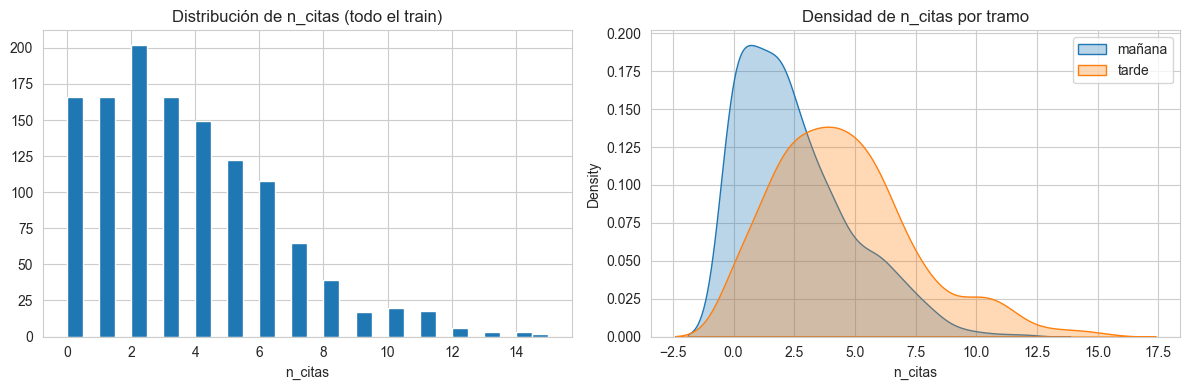

Skewness global: 0.94

Descriptivos por tramo:
        count      mean       std  min  25%  50%  75%   max
tramo                                                      
mañana  626.0  2.522364  2.275500  0.0  1.0  2.0  4.0  12.0
tarde   626.0  4.543131  2.910762  0.0  2.0  4.0  6.0  15.0

% de días-tramo con 0 citas, por tramo:
tramo
mañana    21.1
tarde      5.4
Name: n_citas, dtype: float64


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

train[TARGET].hist(bins=30, ax=axes[0])
axes[0].set_title('Distribución de n_citas (todo el train)')
axes[0].set_xlabel('n_citas')

for tramo, color in zip(['mañana', 'tarde'], ['#8a6bbf', '#4a2e8a']):
    sns.kdeplot(train.loc[train['tramo'] == tramo, TARGET], ax=axes[1], label=tramo, fill=True, alpha=0.3)
axes[1].set_title('Densidad de n_citas por tramo')
axes[1].legend()
plt.tight_layout()
plt.show()

print(f"Skewness global: {train[TARGET].skew():.2f}")
print("\nDescriptivos por tramo:")
print(train.groupby('tramo')[TARGET].describe())
print("\n% de días-tramo con 0 citas, por tramo:")
print((train.groupby('tramo')[TARGET].apply(lambda s: (s == 0).mean()) * 100).round(1))

**Lectura:** asimetría moderada (0,94) — hay días de mucha demanda pero son raros, no hace
falta transformar el target. Mañana y tarde son claramente dos escalas distintas (2,5 vs.
4,5 de media), así que a partir de aquí siempre analizamos por tramo por separado. Y ojo a
los ceros: el 21% de las mañanas no tienen ninguna cita, frente a solo el 5% de las tardes
— con esto el MAPE queda descartado como métrica (no se puede calcular sobre reales a 0),
usaremos MAE o RMSE.

## 3. Target vs. variables de calendario

Cómo se relaciona `n_citas` con cada variable — esto es lo que decide qué features
construir después. Siempre por tramo, nunca agregado.

### 3.1 Tramo

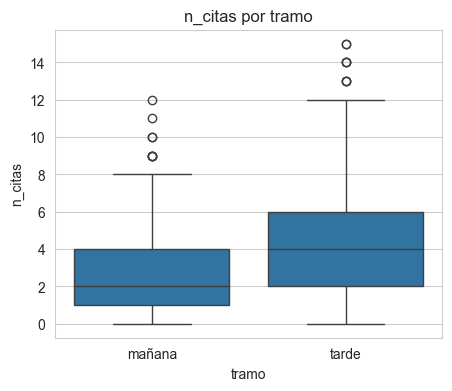

tramo
mañana    2.52
tarde     4.54
Name: n_citas, dtype: float64


In [ ]:
# tramo
plt.figure(figsize=(5, 4))
sns.boxplot(data=train, x='tramo', y=TARGET)
plt.title('n_citas por tramo')
plt.show()

print(train.groupby('tramo')[TARGET].mean().round(2))

**Lectura:** la tarde casi duplica a la mañana (4,54 vs. 2,52) — es la variable individual
con más peso, el modelo la necesita sí o sí.

### 3.2 Día de la semana

¿La demanda sube poco a poco a lo largo de la semana, o hay saltos?

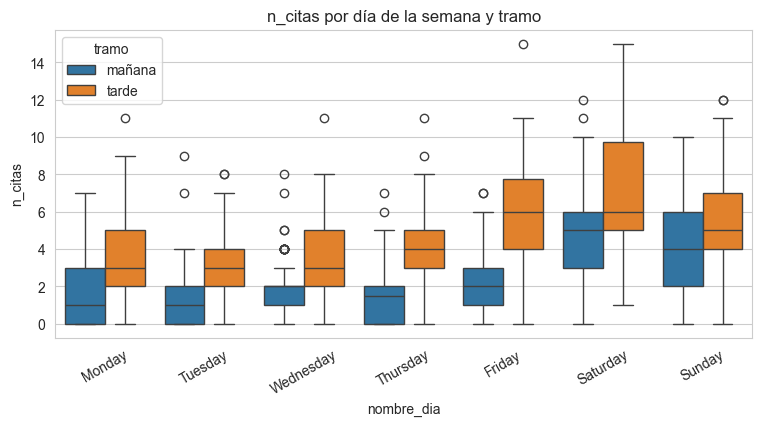

tramo,mañana,tarde
nombre_dia,,
Monday,1.674157,3.303371
Tuesday,1.449438,2.898876
Wednesday,1.797753,3.348315
Thursday,1.600000,3.900000
Friday,2.344444,6.055556
Saturday,4.722222,6.922222
Sunday,4.056180,5.337079


In [ ]:
# día de la semana (por tramo, para no mezclar escalas)
plt.figure(figsize=(9, 4))
sns.boxplot(data=train, x='nombre_dia', y=TARGET, hue='tramo', order=DIAS_ORDEN)
plt.title('n_citas por día de la semana y tramo')
plt.xticks(rotation=30)
plt.show()

tabla_dow = train.groupby(['nombre_dia', 'tramo'])[TARGET].mean().unstack().reindex(DIAS_ORDEN)
tabla_dow

**Lectura:** hay saltos, no gradiente. De lunes a jueves la demanda está plana y baja. El
**viernes** despega, pero solo por la tarde (6,1). El **sábado** es el pico absoluto (4,7
mañana / 6,9 tarde), y el **domingo** destaca sobre todo por la mañana (4,1, más del doble
que cualquier mañana entre semana). Con esto vale más una categoría (entre semana /
viernes / fin de semana) que el número de día tal cual — es el origen de `grupo_dia`.

### 3.3 Mes (estacionalidad anual)

¿Hay meses sistemáticamente más fuertes que otros?

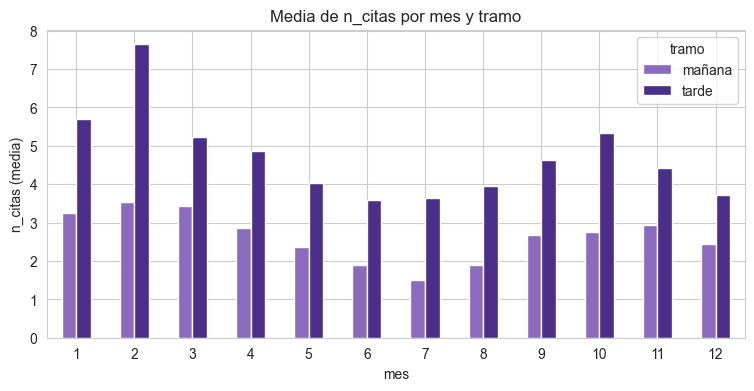

tramo,mañana,tarde
mes,,
1,3.254545,5.709091
2,3.535714,7.642857
3,3.419355,5.225806
4,2.866667,4.866667
5,2.370370,4.018519
6,1.883333,3.600000
7,1.500000,3.645161
8,1.887097,3.951613
9,2.666667,4.633333


In [ ]:
# mes (estacionalidad anual, por tramo)
tabla_mes = train.groupby(['mes', 'tramo'])[TARGET].mean().unstack()
tabla_mes.plot(kind='bar', figsize=(9, 4), color=['#8a6bbf', '#4a2e8a'])
plt.title('Media de n_citas por mes y tramo')
plt.ylabel('n_citas (media)')
plt.xticks(rotation=0)
plt.show()

tabla_mes

**Lectura:** sí, y con lógica de negocio clara — pico en **invierno** (febrero, con
diferencia), valle en **verano**. Un spa es plan de frío, y en Sevilla el verano compite
con playa y vacaciones. Un detalle a cuidar: diciembre y enero se comportan parecido pero
son extremos opuestos en la escala numérica del mes (12 y 1) — mejor agrupar por
`temporada` que dejar que un modelo trate el mes como un número lineal. Por lo que puede interesar hacer una variable de trimestre que recoja las estaciones.

### 3.4 Fin de semana vs. entre semana

Versión resumen del punto anterior: ¿cuánto vale el fin de semana en bloque?

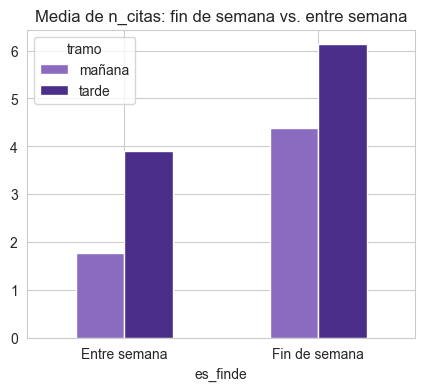

tramo,mañana,tarde
es_finde,,
Entre semana,1.774049,3.906040
Fin de semana,4.391061,6.134078


In [ ]:
# fin de semana vs. entre semana
tabla_finde = train.groupby(['es_finde', 'tramo'])[TARGET].mean().unstack()
tabla_finde.index = tabla_finde.index.map({True: 'Fin de semana', False: 'Entre semana'})
tabla_finde.plot(kind='bar', figsize=(5, 4), color=['#8a6bbf', '#4a2e8a'])
plt.title('Media de n_citas: fin de semana vs. entre semana')
plt.xticks(rotation=0)
plt.show()

tabla_finde

**Lectura:** el fin de semana multiplica la mañana por 2,5 y sube la tarde un 57%. Pero
esta variable esconde al viernes, que ya vimos que se comporta como fin de semana solo por
la tarde — por eso `grupo_dia` (con el viernes aparte) sustituirá a `es_finde`.

### 3.5 Tendencia de fondo

Falta la tercera pieza de cualquier serie temporal: ¿el negocio crece con el tiempo?
Agregamos por semana para ver la dirección sin el ruido diario.

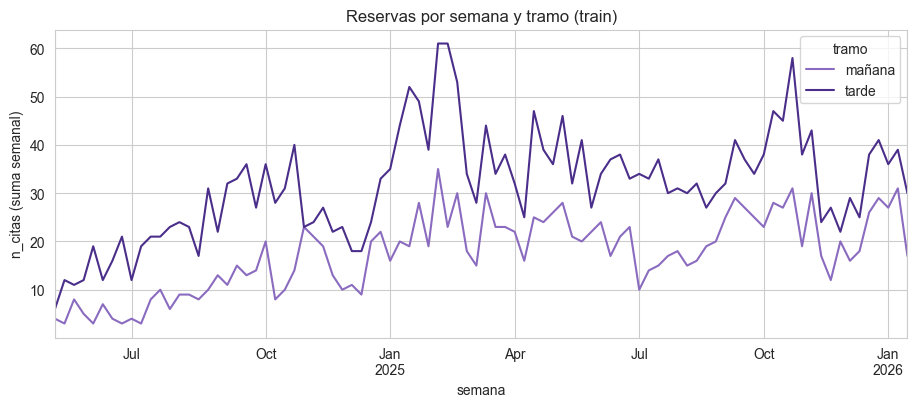

In [ ]:
# tendencia de fondo: evolución semanal por tramo
semanal = (
    train.assign(semana=train['fecha_cita'] - pd.to_timedelta(train['dia_semana'], unit='D'))
         .groupby(['semana', 'tramo'])[TARGET].sum()
         .unstack()
)
semanal.plot(figsize=(11, 4), color=['#8a6bbf', '#4a2e8a'])
plt.title('Reservas por semana y tramo (train)')
plt.ylabel('n_citas (suma semanal)')
plt.show()

**Lectura:** crecimiento claro, sobre todo en 2024 (de ~10-20 citas semanales al abrir a
60-90 un año después); a partir de mediados de 2025 se estabiliza más, con los picos de
invierno por encima. Como esto es tendencia y no calendario, hace falta una variable
aparte (`dias_desde_inicio`) — las variables cíclicas no distinguen un año de otro.

## 4. Correlaciones y outliers

### 4.1 Correlaciones

Convertimos `es_finde` y `tramo` a 0/1 para poder incluirlas. Aviso: Pearson solo mide
relación lineal — para algo cíclico como `mes` es casi ciego (diciembre y enero son
vecinos en la realidad, opuestos en la escala), así que una correlación baja ahí no
significa que el mes no importe.

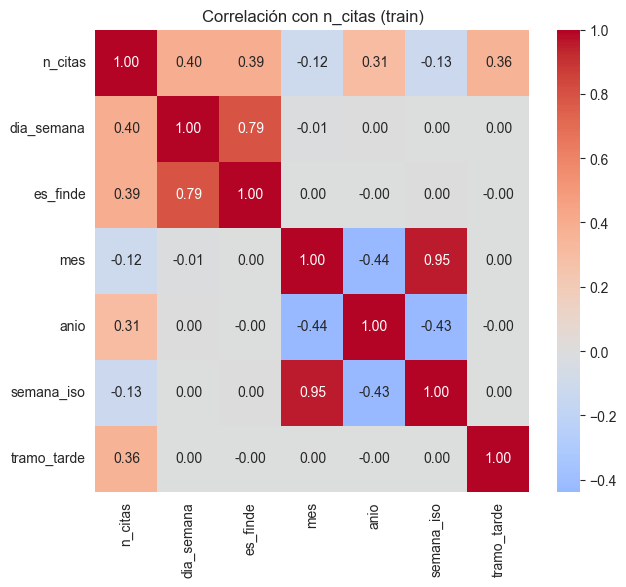

In [ ]:
corr_df = train.copy()
corr_df['es_finde'] = corr_df['es_finde'].astype(int)
corr_df['tramo_tarde'] = (corr_df['tramo'] == 'tarde').astype(int)

corr = corr_df[['n_citas', 'dia_semana', 'es_finde', 'mes', 'anio', 'semana_iso', 'tramo_tarde']].corr()

plt.figure(figsize=(7, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlación con n_citas (train)')
plt.show()

**Lectura:** lo más correlacionado con el target es `dia_semana` (0,40), `es_finde` (0,39),
`tramo_tarde` (0,36) y `anio` (0,31) — coincide con todo lo visto. `mes` y `semana_iso`
salen casi a cero, pero es la ceguera de Pearson ante ciclos, no que no importen (la
sección 3.3 ya lo demostró). `dia_semana` y `es_finde` están muy correlacionadas entre sí
(una deriva de la otra) — redundancia que resolveremos quedándonos con `grupo_dia`.

### 4.2 Outliers
Lo interesante no es cuántos hay, sino si son errores o demanda real.

In [ ]:
# outliers por IQR, calculados por separado en cada tramo (escalas distintas)
def outliers_iqr(serie):
    q1, q3 = serie.quantile(0.25), serie.quantile(0.75)
    iqr = q3 - q1
    lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    return (serie < lo) | (serie > hi)

for tramo in ['mañana', 'tarde']:
    sub = train.loc[train['tramo'] == tramo, TARGET]
    mask = outliers_iqr(sub)
    print(f"Tramo {tramo}: {mask.sum()} outliers de {len(sub)} ({mask.mean()*100:.1f}%)")

train.loc[
    train.groupby('tramo')[TARGET].transform(outliers_iqr)
].sort_values(TARGET, ascending=False).head(16)

Tramo mañana: 8 outliers de 626 (1.3%)
Tramo tarde: 8 outliers de 626 (1.3%)


,fecha_cita,tramo,n_citas,dia_semana,nombre_dia,es_finde,mes,anio,semana_iso
563,2025-02-14,tarde,15,4,Friday,False,2,2025,7
1083,2025-11-01,tarde,15,5,Saturday,True,11,2025,44
579,2025-02-22,tarde,14,5,Saturday,True,2,2025,8
271,2024-09-21,tarde,14,5,Saturday,True,9,2024,38
565,2025-02-15,tarde,14,5,Saturday,True,2,2025,7
551,2025-02-08,tarde,13,5,Saturday,True,2,2025,6
1069,2025-10-25,tarde,13,5,Saturday,True,10,2025,43
495,2025-01-11,tarde,13,5,Saturday,True,1,2025,2
564,2025-02-15,mañana,12,5,Saturday,True,2,2025,7
606,2025-03-08,mañana,11,5,Saturday,True,3,2025,10


**Lectura:** muy pocos (1,3% por tramo) y todos por arriba. Al mirar las fechas, son
sábados y días de febrero (San Valentín, sábados alrededor) — demanda real en fechas pico,
no errores. Se mantienen todos: son justo lo que el modelo tiene que aprender a predecir.

## 5. Tres preguntas más

### 5.1 Día de la semana × mes

¿El sábado pega igual de fuerte en febrero que en julio, o cambia con la temporada?

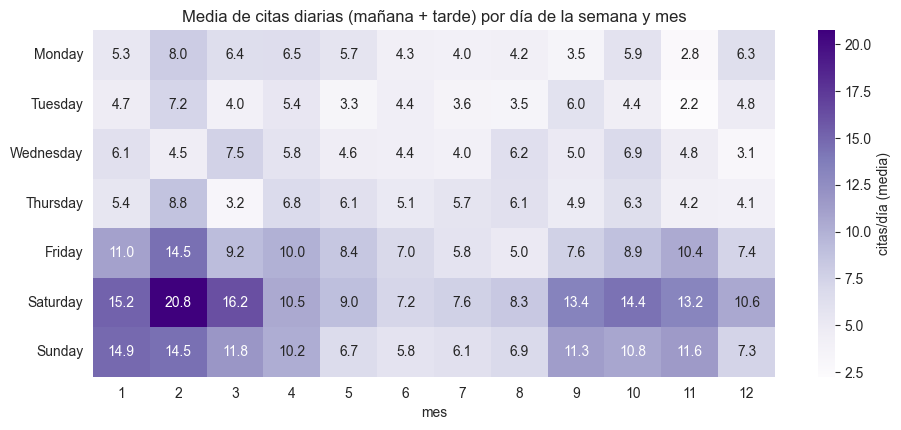

In [11]:
diario = train.groupby('fecha_cita').agg(
    n_citas=('n_citas', 'sum'),
    dia_semana=('dia_semana', 'first'),
    mes=('mes', 'first'),
)

pivot = diario.pivot_table(index='dia_semana', columns='mes', values='n_citas', aggfunc='mean')
pivot.index = [DIAS_ORDEN[i] for i in pivot.index]

plt.figure(figsize=(11, 4.5))
sns.heatmap(pivot, annot=True, fmt='.1f', cmap='Purples', cbar_kws={'label': 'citas/día (media)'})
plt.title('Media de citas diarias (mañana + tarde) por día de la semana y mes')
plt.xlabel('mes')
plt.ylabel('')
plt.show()

**Lectura:** cambia mucho — los efectos se amplifican entre sí. El sábado de febrero llega
a 20,8 citas/día de media; el sábado de julio se queda en 7,6. En verano la semana entera
se aplana (sábado apenas duplica a un martes); en febrero el sábado casi lo quintuplica.
Los modelos de árboles capturan esto solos, sin que haga falta crear la interacción a
mano — otro punto a favor de árboles/gradient boosting para este problema.

### 5.2 Crecimiento interanual: ¿estación o tendencia?

Para separar ambas cosas, comparamos el mismo mes en años distintos.

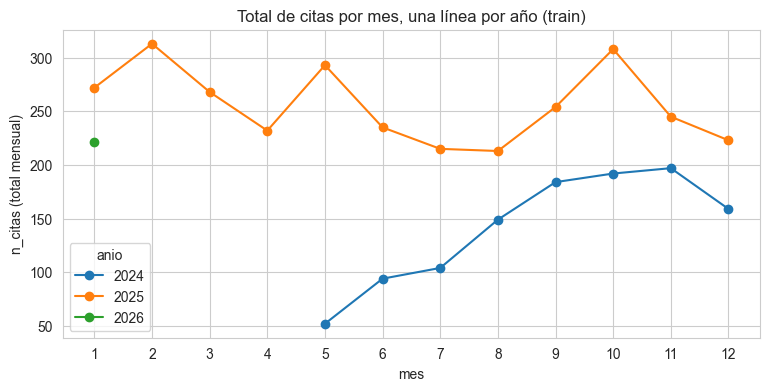

anio,2024,2025,2026
mes,,,
1,NaN,272.0,221.0
2,NaN,313.0,NaN
3,NaN,268.0,NaN
4,NaN,232.0,NaN
5,52.0,293.0,NaN
6,94.0,235.0,NaN
7,104.0,215.0,NaN
8,149.0,213.0,NaN
9,184.0,254.0,NaN


In [12]:
mensual = train.groupby(['anio', 'mes'])['n_citas'].sum().unstack('anio')

mensual.plot(figsize=(9, 4), marker='o')
plt.title('Total de citas por mes, una línea por año (train)')
plt.ylabel('n_citas (total mensual)')
plt.xticks(range(1, 13))
plt.show()

mensual

**Lectura:** es crecimiento real, no solo estación — mayo pasa de 52 citas (2024) a 293
(2025), ×5,6. La brecha entre años se estrecha con el tiempo, coherente con el
"aplanamiento" que vimos en 3.5. Aviso: 2024 solo tiene datos desde mayo (apertura), y el
único punto de 2026 (enero) es un mes incompleto por el corte del split — no leerlo como
caída.

### 5.3 Días sin ninguna cita: ¿demanda cero o cierre?

No es lo mismo "no vino nadie" que "estaba cerrado". Miramos los días con cero citas en
ambos tramos a la vez.

In [13]:
total_diario = train.groupby('fecha_cita')['n_citas'].sum()
dias_cero = total_diario[total_diario == 0]

print(f"Días con cero citas en ambos tramos: {len(dias_cero)} de {len(total_diario)} "
      f"({len(dias_cero) / len(total_diario) * 100:.1f}%)\n")
for fecha in dias_cero.index:
    print(fecha.strftime('%Y-%m-%d  %A'))

Días con cero citas en ambos tramos: 23 de 626 (3.7%)

2024-05-22  Wednesday
2024-05-28  Tuesday
2024-06-23  Sunday
2024-07-07  Sunday
2024-07-22  Monday
2024-08-13  Tuesday
2024-08-23  Friday
2024-11-25  Monday
2024-12-13  Friday
2024-12-25  Wednesday
2025-01-01  Wednesday
2025-01-06  Monday
2025-03-09  Sunday
2025-03-10  Monday
2025-03-11  Tuesday
2025-03-12  Wednesday
2025-03-13  Thursday
2025-11-17  Monday
2025-11-18  Tuesday
2025-11-19  Wednesday
2025-12-25  Thursday
2026-01-01  Thursday
2026-01-06  Tuesday


**Lectura:** 23 días (3,7%), y la mayoría son cierres, no demanda cero: Navidad, Año Nuevo
y Reyes se repiten los dos años, y hay dos bloques seguidos (9-13 marzo y 17-19 noviembre
de 2025) que tienen toda la pinta de vacaciones u obras. El resto son días sueltos de
2024, cuando el negocio acababa de abrir.

Esto explica algo importante: `es_festivo` salió muy débil en Feature Engineering porque
mezcla dos efectos opuestos que se cancelan (festivos que cierran el spa vs. festivos que
traen más clientes). Y para Preprocesado: esos cierres no son predecibles desde el
calendario público, conviene marcarlos o excluirlos de train.

## 6. Conclusiones

**Para Feature Engineering:**

- `tramo` manda en la escala (tarde casi dobla a mañana) → `tramo_tarde` numérica.
- El patrón semanal da saltos, no gradiente (plano L-J, sube viernes tarde, pico fin de
  semana) → `grupo_dia` en vez de `dia_semana`/`es_finde` a solas.
- Estacionalidad anual clara (invierno arriba, verano abajo, diciembre-enero pegados) →
  `temporada` en vez de confiar en `mes` como número lineal.
- Tendencia de crecimiento real (mayo ×5,6 de 2024 a 2025) → variable de tendencia
  (`dias_desde_inicio`), las cíclicas no la capturan.
- Dataset limpio, outliers pocos y explicables como demanda real en fechas pico → no se
  toca nada.

**Avisos para más adelante:**

- MAPE inviable (21% de mañanas a 0) → MAE o RMSE.
- El efecto fin de semana se dispara en temporada alta — favorece modelos de árboles sobre
  lineales.
- Hay cierres reales del negocio (Navidad/Reyes + dos bloques en 2025) mezclados con
  demanda cero — por eso `es_festivo` sale débil, y en Preprocesado convendría marcarlos.